# AnalyticBilliard from Python

A billiard solved **collision to collision in closed form** — no time stepping, so there is no integration error to accumulate. Between bounces the particle follows an exact parabola, and each collision time is a root of a polynomial.

The workflow is:

1. describe a scene as a dict
2. `compileScene` once — this is the only step that runs a compiler
3. run it as often as you like, changing parameters, gravity and initial conditions **without rebuilding**

Only *adding, removing or retyping* an object needs a new compile.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hpcBilliards import compileScene, updateScene, SceneError

## 1. Describing a scene

`solidObjects` are things that reflect. Four types, each with a fixed parameter count:

| type | params | meaning |
|---|---|---|
| `line` | 3 | `a, b, c` of `a*x + b*y + c = 0` |
| `lineSegment` | 4 | `x0, y0, x1, y1` |
| `elipse` | 5 | `x0, y0, a, b, theta` |
| `elipseArc` | 7 | the ellipse's five, then `phi0, phi1` |

There is **no circle type** — a circle is an ellipse with equal radii.

A box with a floor, a ceiling and two walls:

In [2]:
box = {
    "g": 1.0,          # gravity, pulling towards -y
    "deadTime": 1e-9,  # roots below this are the collision just resolved

    "solidObjects": [
        {"type": "line", "params": [0.0, 1.0, 0.0]},     # floor    y = 0
        {"type": "line", "params": [0.0, 1.0, -10.0]},   # ceiling  y = 10
        {"type": "line", "params": [1.0, 0.0, 20.0]},    # wall     x = -20
        {"type": "line", "params": [1.0, 0.0, -20.0]},   # wall     x = 20
    ],
}

billiard = compileScene(box, backend="linear")
print(billiard.types, "->", billiard.so_path.name, "cached:", billiard.cached)

['line', 'line', 'line', 'line'] -> libab.so cached: True


`backend=` picks how it is built:

- `"linear"` — plain serial
- `"openmp"` — across CPU cores, one particle per thread
- `"gpu_openmp"` — offloaded to the GPU

All three give **bitwise identical** results, which is the point: a chaotic trajectory that differed in the last bit would diverge completely.

## 2. Running it

Initial conditions are arrays, one entry per particle. Stop either after a number of events (`iterations=`) **or** after an amount of time (`tf=`) — never both.

In [3]:
x = [-16.0, -16.0, -16.0]
y = [1.0, 3.0, 5.0]
vx = [5.75, 5.0, 4.5]
vy = [4.25, 3.0, 2.0]

run = billiard.recordScene(x, y, vx, vy, iterations=200)
run

<Record 3 particles x 201 rows, columns=['t', 'x', 'y', 'vx', 'vy', 'evType'], counts=[201, 201, 201]>

### The shape of what comes back

Every column is a 2-D array of shape `(nParticles, maxRows)`. **The particle index is the first axis** — there is no `ID` column, because the axis already is the id.

Particles can produce different numbers of rows, so the arrays are padded and `counts` says where each one's real data ends.

In [4]:
print("run.x.shape :", run.x.shape, " (particle, event)")
print("run.counts  :", run.counts)
print()
print("run.x[1]    : particle 1, every event  ->", run.x[1].shape)
print("run.x[:, 0] : every particle, 1st event ->", run.x[:, 0])
print()
print("trim(1) slices particle 1 to its real rows:")
print({k: v.shape for k, v in run.trim(1).items()})

run.x.shape : (3, 201)  (particle, event)
run.counts  : [201 201 201]

run.x[1]    : particle 1, every event  -> (201,)
run.x[:, 0] : every particle, 1st event -> [-16. -16. -16.]

trim(1) slices particle 1 to its real rows:
{'t': (201,), 'x': (201,), 'y': (201,), 'vx': (201,), 'vy': (201,), 'evType': (201,)}


### A row is a state, not an interval

Each row is the state **just after** an event, which is the initial condition for the flight that follows. The flight's *end* is simply the next row, so nothing is stored twice — there is no duration column.

That makes the arc between two rows an exact parabola you can rebuild:

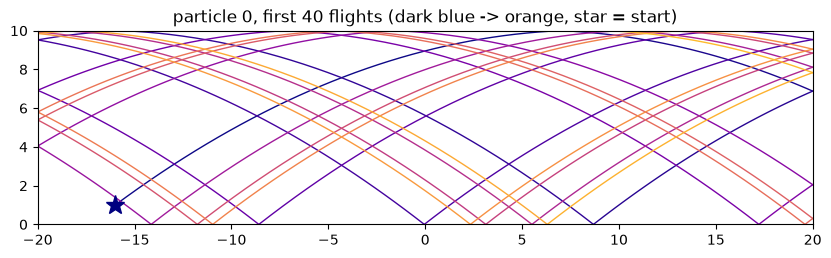

In [5]:
def draw(ax, run, particle, g, nArcs=40):
    p = run.trim(particle)
    n = min(len(p["t"]), nArcs + 1)
    for i in range(n - 1):
        s = np.linspace(0.0, p["t"][i + 1] - p["t"][i], 40)   # this flight
        ax.plot(p["x"][i] + p["vx"][i] * s,
                p["y"][i] + p["vy"][i] * s - 0.5 * g * s * s,
                color=plt.cm.plasma(0.85 * i / max(n - 2, 1)), lw=1)
    ax.plot(p["x"][0], p["y"][0], "*", ms=14, color="navy", zorder=5)


fig, ax = plt.subplots(figsize=(10, 3.2))
draw(ax, run, 0, box["g"])
ax.set_xlim(-20, 20); ax.set_ylim(0, 10); ax.set_aspect("equal")
ax.set_title("particle 0, first 40 flights (dark blue -> orange, star = start)")
plt.show()

## 3. Choosing what to record

`save=` picks columns from `t, x, y, vx, vy, Energy, evType`. It decides what gets **allocated**, not just what you get handed back — so asking for less really costs less.

`Energy` is the total, per unit mass: `0.5*(vx**2 + vy**2) + g*y`.

`evType` marks what happened: `0` initial, `1` bounce, `2` portal.

In [6]:
energyOnly = billiard.recordScene(x, y, vx, vy, iterations=20000,
                                  save=["Energy"])

e = energyOnly.trim(0)["Energy"]
print(f"{e.size} events, E starts at {e[0]:.6f}")
print(f"total drift over the run: {e[-1] - e[0]:+.2e}")
print(f"spread:                   {np.ptp(e):.2e}")

20001 events, E starts at 26.562500
total drift over the run: -1.24e-13
spread:                   2.06e-13


That drift is the honest error of the whole method: no timestep, so nothing accumulates except floating-point rounding at each collision.

### Stopping by time instead

`tf=` cannot know in advance how many rows it needs, so give it `maxRows` and check `truncated` afterwards.

In [7]:
timed = billiard.recordScene(x, y, vx, vy, tf=200.0, maxRows=5000)
print("rows used :", timed.counts)
print("truncated :", timed.truncated, " (1 = it ran out of room)")

try:
    billiard.recordScene(x, y, vx, vy, iterations=100, tf=10.0)
except ValueError as err:
    print("\niterations= and tf= are exclusive:", err)

rows used : [76 51 49]
truncated : [0 0 0]  (1 = it ran out of room)

iterations= and tf= are exclusive: give exactly one of iterations= or tf= (they are mutually exclusive)


## 4. Changing the scene without recompiling

This is the part worth understanding. `updateScene(newScene, compiled)` pushes new numbers into the library already loaded.

**No rebuild:** any object's parameters, the portal flips, `g`, `deadTime`.

**Rebuild required:** adding or removing an object, changing an object's type.

Watch the `.so` file stay untouched while gravity and the floor's tilt both change:

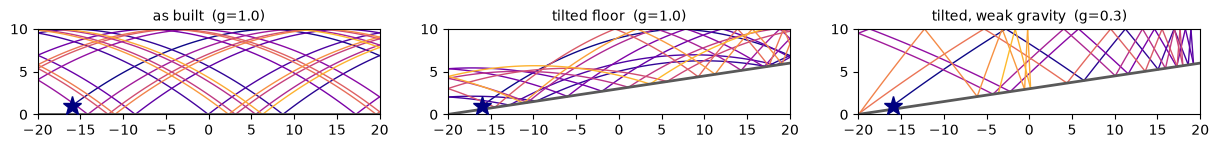

library rebuilt? False


In [8]:
before = billiard.so_path.stat().st_mtime

# The floor is hinged at the LEFT wall and rises to the right:
#     y = tilt*(x + 20)   ->   -tilt*x + y - 20*tilt = 0
#
# Hinging it at the origin instead (params [tilt, 1, 0]) would put the floor at
# y = 2.4 under the start points, which sit at y = 1..5. They would begin
# OUTSIDE the billiard, fall straight through, and never come back.
def tiltedBox(tilt, g):
    return {"g": g, "deadTime": 1e-9,
            "solidObjects": [
                {"type": "line", "params": [-tilt, 1.0, -20.0 * tilt]},  # floor
                {"type": "line", "params": [0.0, 1.0, -10.0]},
                {"type": "line", "params": [1.0, 0.0, 20.0]},
                {"type": "line", "params": [1.0, 0.0, -20.0]},
            ]}


fig, axes = plt.subplots(1, 3, figsize=(15, 3.0))

for ax, (label, tilt, g) in zip(axes, [("as built", 0.0, 1.0),
                                       ("tilted floor", 0.15, 1.0),
                                       ("tilted, weak gravity", 0.15, 0.3)]):
    updateScene(tiltedBox(tilt, g), billiard)      # no compiler runs on this line

    r = billiard.recordScene(x, y, vx, vy, iterations=120)
    draw(ax, r, 0, g)
    ax.plot([-20, 20], [0.0, 40.0 * tilt], color="0.35", lw=2)   # the floor
    ax.set_xlim(-20, 20); ax.set_ylim(0, 10); ax.set_aspect("equal")
    ax.set_title(f"{label}  (g={g})", fontsize=10)

    # worth asserting rather than trusting: a particle that starts under the
    # floor falls out silently, and the axis limits would hide it
    p = r.trim(0)
    assert (p["y"] >= tilt * (p["x"] + 20.0) - 1e-9).all(), "particle escaped!"

plt.show()
print("library rebuilt?", billiard.so_path.stat().st_mtime != before)

Changing the *structure* is refused, rather than quietly doing the wrong thing:

In [9]:
try:
    updateScene({"g": 1.0, "solidObjects": [
        {"type": "line", "params": [0.0, 1.0, 0.0]},
    ]}, billiard)                      # three objects short
except SceneError as err:
    print("SceneError:", err)

SceneError: scene has 1 objects, the compiled one has 4: objects cannot be added or removed without recompiling


## 5. Portals

A portal moves a particle to a partner surface instead of reflecting it. One dict is **one one-way portal**: enter `entryParams`, leave at `exitParams`. Write two dicts for a two-way pair.

```python
{"entry": "lineSegment", "entryParams": [...],
 "exit":  "lineSegment", "exitParams":  [...],
 "normalFlip": +1.0, "tangentFlip": +1.0}
```

The two flips act on the **velocity only**, never the position:

- `normalFlip = -1` — leaves by the face it arrived at, so it turns back
- `tangentFlip = -1` — runs the other way along the exit; goes in climbing, comes out descending

*Where* it comes out is set by the order you wrote the exit endpoints in. Both flips are parameters, so they change without a rebuild.

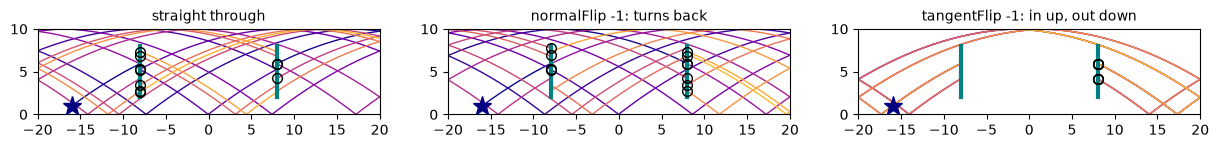

teal = portals, hollow circles = where a portal put the particle down


In [10]:
def portalBox(normalFlip=1.0, tangentFlip=1.0):
    return {"g": 1.0, "deadTime": 1e-9,
            "solidObjects": [
                {"type": "line", "params": [0.0, 1.0, 0.0]},
                {"type": "line", "params": [0.0, 1.0, -10.0]},
                {"type": "line", "params": [1.0, 0.0, 20.0]},
                {"type": "line", "params": [1.0, 0.0, -20.0]},
            ],
            "portalObjects": [
                {"entry": "lineSegment", "entryParams": [-8.0, 2.0, -8.0, 8.0],
                 "exit":  "lineSegment", "exitParams":  [8.0, 2.0, 8.0, 8.0],
                 "normalFlip": normalFlip, "tangentFlip": tangentFlip},
                {"entry": "lineSegment", "entryParams": [8.0, 2.0, 8.0, 8.0],
                 "exit":  "lineSegment", "exitParams":  [-8.0, 2.0, -8.0, 8.0],
                 "normalFlip": normalFlip, "tangentFlip": tangentFlip},
            ]}


portals = compileScene(portalBox(), backend="linear")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.0))
cases = [("straight through", 1.0, 1.0),
         ("normalFlip -1: turns back", -1.0, 1.0),
         ("tangentFlip -1: in up, out down", 1.0, -1.0)]

for ax, (label, nf, tf_) in zip(axes, cases):
    updateScene(portalBox(nf, tf_), portals)     # flips are parameters too
    r = portals.recordScene([-16.0], [1.0], [5.75], [4.25], iterations=40,
                            save=["t", "x", "y", "vx", "vy", "evType"])
    draw(ax, r, 0, 1.0)
    for xs in (-8.0, 8.0):
        ax.plot([xs, xs], [2.0, 8.0], color="teal", lw=3, zorder=4)
    p = r.trim(0)
    ax.plot(p["x"][p["evType"] == 2], p["y"][p["evType"] == 2], "o",
            mfc="none", mec="black", ms=7, zorder=6)
    ax.set_xlim(-20, 20); ax.set_ylim(0, 10); ax.set_aspect("equal")
    ax.set_title(label, fontsize=10)

plt.show()
print("teal = portals, hollow circles = where a portal put the particle down")

A level portal pair conserves energy exactly, because the flips move only the velocity:

In [11]:
for label, nf, tf_ in cases:
    updateScene(portalBox(nf, tf_), portals)
    r = portals.recordScene([-16.0], [1.0], [5.75], [4.25], iterations=5000,
                            save=["Energy", "evType"])
    p = r.trim(0)
    print(f"{label:34} crossings {int((p['evType'] == 2).sum()):5d}   "
          f"energy spread {np.ptp(p['Energy']):.2e}")

straight through                   crossings  1307   energy spread 1.07e-13
normalFlip -1: turns back          crossings  1315   energy spread 8.88e-14
tangentFlip -1: in up, out down    crossings   834   energy spread 1.07e-14


## Cheat sheet

```python
compiled = compileScene(scene, backend="linear" | "openmp" | "gpu_openmp")
updateScene(newScene, compiled)          # parameters only, never rebuilds

rec = compiled.recordScene(x, y, vx, vy,
                           iterations=N,          # XOR tf=T, maxRows=M
                           save=["t","x","y","vx","vy","Energy","evType"],
                           eventType=["bounce"])  # or ["portal"]

rec.x            # (nParticles, maxRows), particle index is axis 0
rec.counts       # real rows per particle -- everything past this is padding
rec.truncated    # 1 where a tf run hit maxRows
rec.trim(i)      # particle i, sliced to its real rows, as a dict
```

**Gotchas**

- there is no `"ID"` column — the particle index is the first axis
- there is no `"circle"` type — use `elipse` with equal radii
- always slice with `counts` (or use `trim`); padding is not real data
- initial conditions must lie **inside** the billiard; a particle started on the wrong side of a wall falls out and never returns
- `eventType=["bounce"]` drops the `evType == 0` row, so column 0 becomes the first *collision*, not the initial condition